# L5: Building a Context Engine


<p style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px"> ⏳ <b>Note <code>(Kernel Starting)</code>:</b> This notebook takes about 30 seconds to be ready to use. You may start and watch the video while you wait.</p>

![Building a Context Engine](L5.png)

In [1]:
# Warning control
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import sys
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from dotenv import load_dotenv

sys.path.insert(0, os.path.abspath('..'))
pio.renderers.default = 'png'

load_dotenv()

if not os.getenv('OPENAI_API_KEY'):
    print('⚠️  WARNING: OPENAI_API_KEY not set.')
else:
    print('✓ OpenAI API key loaded successfully')

✓ OpenAI API key loaded successfully


<div style="background-color:#fff6ff; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">
<p> 💻 &nbsp; <b>Access <code>requirements.txt</code> file:</b> 1) click on the <em>"File"</em> option on the top menu of the notebook and then 2) click on <em>"Open"</em>.</p>

<p> ⬇ &nbsp; <b>Download Notebooks:</b> 1) click on the <em>"File"</em> option on the top menu of the notebook and then 2) click on <em>"Download as"</em> and select <em>"Notebook (.ipynb)"</em>.</p>

<p> 📒 &nbsp; For more help, please see the <em>"Appendix – Tips, Help, and Download"</em> Lesson.</p>
</div>

## Section 1: The Repository

In [3]:
from src.data.toy_repository import get_toy_repository

repo = get_toy_repository()

print(f"Repository contains {len(repo)} files:")
for file_path in sorted(repo.keys()):
    lines = len(repo[file_path].splitlines())
    print(f"  • {file_path:30s} ({lines:3d} lines)")

total_lines = sum(len(code.splitlines()) for code in repo.values())
print(f"\nTotal: {total_lines} lines of code")

Repository contains 25 files:
  • app/api/admin.py               ( 53 lines)
  • app/api/analytics.py           ( 60 lines)
  • app/api/auth.py                ( 52 lines)
  • app/api/billing.py             ( 53 lines)
  • app/api/comments.py            ( 63 lines)
  • app/api/email_templates.py     ( 47 lines)
  • app/api/files.py               ( 41 lines)
  • app/api/integrations.py        ( 62 lines)
  • app/api/inventory.py           ( 27 lines)
  • app/api/notifications.py       ( 50 lines)
  • app/api/posts.py               ( 37 lines)
  • app/api/products.py            ( 27 lines)
  • app/api/reports.py             ( 52 lines)
  • app/api/settings.py            ( 54 lines)
  • app/api/tags.py                ( 58 lines)
  • app/api/users.py               ( 53 lines)
  • app/api/webhooks.py            ( 47 lines)
  • app/auth.py                    ( 29 lines)
  • app/config.py                  ( 16 lines)
  • app/legacy/old_api.py          ( 40 lines)
  • app/main.py               

## Section 2: Chunking the Repository

In [4]:
from src.context_engine import chunk_repository

chunks = chunk_repository(repo)
print(f"✓ Created {len(chunks)} chunks\n")

chunk_types = {}
for chunk in chunks:
    chunk_types[chunk.type] = chunk_types.get(chunk.type, 0) + 1

print("Chunk Distribution:")
for chunk_type, count in sorted(chunk_types.items()):
    print(f"  {chunk_type:12s}: {count:2d} chunks")

print("\nSample Chunks:")
for i, chunk in enumerate(chunks[:3]):
    print(f"\n{i+1}. {chunk.type}: {chunk.name} ({chunk.file_path})")
    preview = chunk.content[:150].replace('\n', ' ')
    print(f"   {preview}...")

✓ Created 99 chunks

Chunk Distribution:
  class       : 10 chunks
  function    : 88 chunks
  test        :  1 chunks

Sample Chunks:

1. function: list_users (app/api/users.py)
   def list_users():     """List all users."""     return db.get_all_users()...

2. function: get_user (app/api/users.py)
   def get_user(user_id: int):     """Get a single user by ID."""     return db.get_user(user_id)...

3. function: find_user_by_email (app/api/users.py)
   def find_user_by_email(email: str):     """Find user by email using safe parameterized query."""     user = db.query("SELECT * FROM users WHERE email ...


## Section 3: Create Embeddings

In [5]:
from src.context_engine import embed_chunks

print("Creating embeddings...")
embedded_chunks = embed_chunks(chunks)

print(f"✓ Created {len(embedded_chunks)} embeddings")
print(f"\nEmbedding dimension: {len(embedded_chunks[0]['embedding'])}")
print(f"Sample embedding (first 5 values): "
      f"{embedded_chunks[0]['embedding'][:5]}")

Creating embeddings...
✓ Created 99 embeddings

Embedding dimension: 3072
Sample embedding (first 5 values): [-0.00018310546875, 0.009246826171875, -0.00701904296875, -0.0022430419921875, 0.020233154296875]


## Section 4: Build Vector Index

In [6]:
from src.context_engine import ContextRetriever

retriever = ContextRetriever()
retriever.create_index(embedded_chunks)

print(f"✓ Vector index created with {len(embedded_chunks)} chunks")

✓ Vector index created with 99 chunks


## Section 5: Test Retrieval

In [7]:
from src.data.sample_prs import load_pr

pr = load_pr('pr_002_sql_injection')
query = f"{pr['title']}\n\n{pr['diff']}"

print(f"Query: {pr['title']}\n")
results = retriever.retrieve(query, n_results=10)

print("Top Retrieved Chunks:")
for i, result in enumerate(results[:10], 1):
    meta = result['metadata']
    similarity = 1 - result['distance']
    print(f"{i:2d}. {meta['type']:8s} {meta['name']:30s} "
          f"(similarity: {similarity:+.3f})")

Query: Add user search functionality

Top Retrieved Chunks:
 1. function list_users                     (similarity: +0.054)
 2. function list_all_users                 (similarity: -0.058)
 3. function search_reports                 (similarity: -0.129)
 4. function find_user_by_email             (similarity: -0.166)
 5. function list_invoices                  (similarity: -0.233)
 6. function list_integrations              (similarity: -0.237)
 7. function search_products                (similarity: -0.242)
 8. function get_user                       (similarity: -0.249)
 9. function legacy_search                  (similarity: -0.254)
10. class    User                           (similarity: -0.256)


## Section 6: Context Size Comparison

In [8]:
from src.review_agents.reviewer import review

full_context_chunks = []
for item in embedded_chunks:
    chunk = item['chunk']
    full_context_chunks.append(f"# {chunk.type}: {chunk.name} "
        f"({chunk.file_path})\n{chunk.content}")

full_context = "\n\n".join(full_context_chunks)
selective_context = retriever.retrieve_for_pr(pr, n_results=15)

print(f"Context Sizes:")
print(f"  Full Context:      {len(full_context):,} characters ({len(full_context_chunks)} chunks)")
print(f"  Selective Context: {len(selective_context):,} characters (15 chunks)")
print(f"  Reduction:         {(1 - len(selective_context)/len(full_context))*100:.1f}%")

Context Sizes:
  Full Context:      31,159 characters (99 chunks)
  Selective Context: 3,448 characters (15 chunks)
  Reduction:         88.9%


## Section 7: Full Evaluation

In [9]:
from src.data.sample_prs import load_all_prs

all_prs = load_all_prs()
print(f"Evaluating {len(all_prs)} PRs across three approaches...\n")

results_no_context = []
results_full_context = []
results_selective = []

for i, pr_item in enumerate(all_prs, 1):
    print(f"  {i}/{len(all_prs)}: {pr_item['id']}")
    results_no_context.append({'pr_id': pr_item['id'], 'review': review(pr_item, context=None, task_context=None), 'expected': pr_item['expected_issues']})
    results_full_context.append({'pr_id': pr_item['id'], 'review': review(pr_item, context=full_context, task_context=pr_item.get('task_context', '')), 'expected': pr_item['expected_issues']})
    selective_ctx = retriever.retrieve_for_pr(pr_item, n_results=15)
    results_selective.append({'pr_id': pr_item['id'], 'review': review(pr_item, context=selective_ctx, task_context=pr_item.get('task_context', '')), 'expected': pr_item['expected_issues']})

print(f"\n✓ Evaluation complete")

Evaluating 15 PRs across three approaches...

  1/15: pr_001_auth_bypass
  2/15: pr_002_sql_injection
  3/15: pr_003_hardcoded_secret
  4/15: pr_004_missing_error_handling
  5/15: pr_005_race_condition
  6/15: pr_006_xss_vulnerability
  7/15: pr_007_weak_crypto
  8/15: pr_008_missing_rate_limit
  9/15: pr_009_insecure_deserialization
  10/15: pr_010_missing_input_validation
  11/15: pr_011_info_disclosure
  12/15: pr_012_path_traversal
  13/15: pr_013_cors_misconfiguration
  14/15: pr_014_timing_attack
  15/15: pr_015_unvalidated_redirect

✓ Evaluation complete


<p style="background-color:#f7fff8; padding:15px; border-width:3px; border-color:#e0f0e0; border-style:solid; border-radius:6px"> 🚨
&nbsp; <b>Different Run Results:</b> The output generated by AI chat models can vary with each execution due to their dynamic, probabilistic nature. Don't be surprised if your results differ from those shown in the video.</p>

In [10]:
from src.utils.evaluation import calculate_metrics_from_results
from src.utils.display import display_metrics_table

metrics_no_context = calculate_metrics_from_results(results_no_context)
metrics_full_context = calculate_metrics_from_results(results_full_context)
metrics_selective = calculate_metrics_from_results(results_selective)

display_metrics_table(metrics_no_context, metrics_selective, 
                      metrics_full_context)

,Approach,Precision,Recall,F1 Score
0,No Context,31.37%,53.33%,39.51%
1,Full Context (All Chunks),36.71%,96.67%,53.21%
2,Selective Context (Top 15),44.12%,100.00%,61.22%



Key Insight:
  F1:     Selective vs Full = +8.0%
  Recall: Selective vs Full = +3.3%

✓ Selective context OUTPERFORMS full context!
  → Focused retrieval beats dumping all context


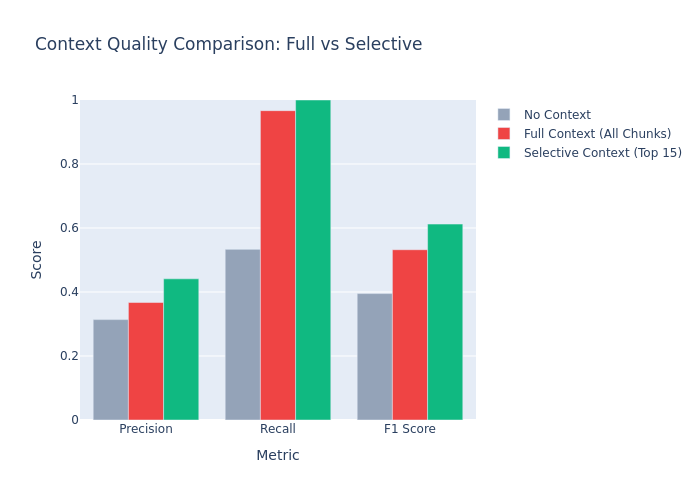

In [11]:
from src.utils.plotting import plot_metrics_comparison

# Create visual comparison of the three approaches
plot_metrics_comparison(metrics_no_context, metrics_selective, metrics_full_context)

## Section 8: Context Size vs Quality

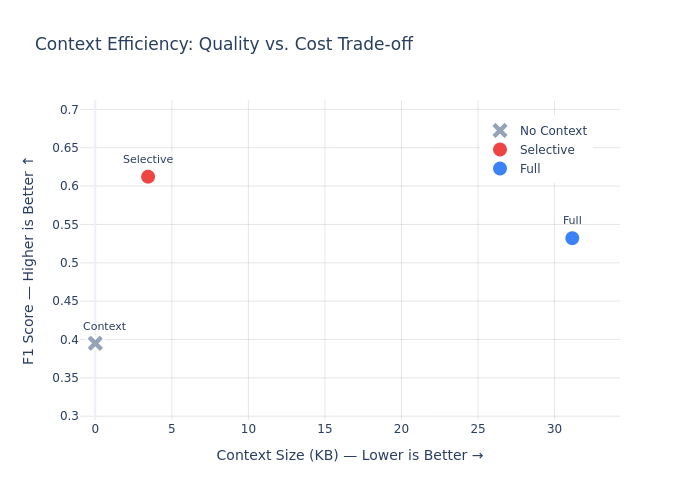


Context Efficiency (F1 per KB):
  Selective: 0.178 F1/KB  ← 10.4x more efficient
  Full:      0.017 F1/KB

Selective achieves 115.1% performance with 11.1% of the context size


In [12]:
from src.utils.plotting import plot_context_efficiency

context_sizes = {
    'No Context': 0,
    'Selective': len(selective_context),
    'Full': len(full_context)
}
f1_scores = {
    'No Context': metrics_no_context['f1'],
    'Selective': metrics_selective['f1'],
    'Full': metrics_full_context['f1']
}
labels = ['No Context', 'Selective', 'Full']

plot_context_efficiency(context_sizes, f1_scores, labels)